# Te damos la bienvenida a Colab

#**1. Introducción**

## 1. Introducción
En los últimos años, plataformas como Airbnb han dejado de ser exclusivamente un espacio para que particulares arrienden sus hogares de forma ocasional. Hoy, una fracción significativa de los anuncios en Europa corresponde a operadores comerciales, agencias inmobiliarias y empresas de gestión vacacional, que operan decenas o cientos de propiedades bajo perfiles de "anfitriones particulares", evadiendo normativas turísticas y distorsionando el mercado de arriendo residencial.

Este fenómeno, conocido como **turistificación**, tiene consecuencias directas sobre el acceso a vivienda en ciudades como Barcelona, Lisboa o París: reduce la oferta de arriendo residencial, infla los precios y transforma barrios enteros en zonas de uso turístico intensivo.

Este proyecto busca abordar este problema desde la minería de datos, utilizando el dataset **Airbnb Market Data Europe** (~95.000 anuncios, 61 variables) complementado con datos históricos mensuales de ocupación y precios (`past_rates`, ~1.1M registros). Juntos, estos datasets permiten analizar no solo el estado actual del mercado, sino también su comportamiento estacional.

El análisis se estructura en torno a cuatro preguntas de investigación que combinan técnicas supervisadas y no supervisadas, y que buscan entregar herramientas concretas para reguladores y organismos de política pública.

## 2. Preguntas de Investigación
Las preguntas fueron definidas tras un análisis exploratorio exhaustivo del dataset, descrito en la sección 3. Se reformularon respecto a una propuesta inicial al verificar qué variables tienen señal real en los datos.

---

**P1 — Clustering (No Supervisado): Segmentación de mercados urbanos**
¿Qué perfiles de turistificación emergen al agrupar ciudades europeas según su ocupación real, variabilidad estacional y precio promedio?
*Variables: `occ_media`, `occ_std`, `rate_media`, `revenue_total` por ciudad. Valor: genera un mapa empírico de saturación turística para justificar normativas de zonificación.*

---

**P2 — Regresión (Supervisado): Índice de precio base europeo**
¿Qué variables físicas y operativas determinan el precio de un alojamiento europeo, y qué ciudades presentan precios por encima de lo esperado?
*Variables: `guests`, `occ_media`, `lead_time_media`, `room_type`, `city`. Target: `rate_media`. El residuo del modelo identifica ciudades con sobreprecio especulativo.*

---

**P3 — Clasificación (Supervisado): Detección de gestión profesional encubierta**
¿Es posible identificar anuncios operados comercialmente a partir de sus métricas de rendimiento económico y comportamiento de reservas?
*Variables: `revenue_total`, `occ_std`, `lead_time_media`, `rate_std`, `rating_overall`, `city`. Target: `professional_management`.*

---

**P4 — Detección de Anomalías (No Supervisado): Colusión espacial de precios**
¿Existen zonas geográficas donde distintos hosts mantienen precios inusualmente similares e inflados respecto al promedio de su ciudad?
*Variables: `latitude`, `longitude`, `rate_media`, `rate_std`, `host_id`, `city`.*

#**3. Exploración de Datos**

Esta sección cubre la carga, auditoría, limpieza e integración de los datos. El objetivo es llegar a un dataset único y limpio (df_full) que sirva de base para todos los modelos.

## 3.1 Carga del Dataset
Cargamos el dataset principal desde el repositorio del proyecto. Usamos el formato `.parquet` en vez del `.csv` original, ya que este último presentaba errores de parseo que corrompían varias columnas.

In [ ]:
!pip -q install pyarrow

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
pd.set_option('future.no_silent_downcasting', True)

url = "https://raw.githubusercontent.com/Rajevic-0/Proyecto-Mineria-De-Datos/21614a18231f34a2f38d2e238fca764d134ef4a2/listings.parquet"

try:
    df_init = pd.read_parquet(url, engine="pyarrow")
    print(f"Carga exitosa — {df_init.shape[0]:,} registros × {df_init.shape[1]} columnas")
except Exception as e:
    print(f"Error: {e}")

df_init.head(3)

Carga exitosa — 95,898 registros × 61 columnas


,listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,...,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,country,state,city
0,121902,Entire home,entire_home,https://a0.muscache.com/im/pictures/77c0e3a9-0...,77,fe453949b595,false,37.0758,27.2426,6,...,0.0,0.0,0.0,0,90,90,90,Turkey,Muğla,Bodrum
1,805342,Entire condo,entire_home,https://a0.muscache.com/im/pictures/11494599/4...,16,59711ec4c245,false,37.0092,27.2563,3,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum
2,805361,Entire home,entire_home,https://a0.muscache.com/im/pictures/bda48dbc-d...,34,d217bf6e3427,false,37.0292,27.4410,5,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum


##**3.2 Auditoría Inicial**

Antes de cualquier limpieza, auditamos el dataset para entender su estructura: tipos de datos, presencia de nulos y duplicados.

In [ ]:
df_init.describe()

,listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,...,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,country,state,city
count,95898,95329,95329,95102,95102,95329,95322,95327,95273,84865,...,95329,95329,95329,95329,95329,95329,94854,95898,95898,95898
unique,95882,129,485,94429,689,68528,473,55034,63476,24,...,6114,2670,4254,94,93,92,5,36,136,373
top,"⭐⭐⭐⭐⭐""",Entire rental unit,entire_home,18,16,ad1c8827240f,false,40.6318,4,4,...,0.0,0.0,0.0,0,0,90,90,France,England,Olbia
freq,6,47104,81709,19,3103,81,52890,28,142,26729,...,37224,71407,71044,37136,56248,37331,94850,25253,8650,308


In [ ]:
print("AUDITORÍA INICIAL")
print("="*55)
print(f"Registros : {df_init.shape[0]:,}")
print(f"Columnas  : {df_init.shape[1]}")
print(f"\n--- Tipos de columnas ---")
print(df_init.dtypes.value_counts())

# Nulos
nulls_pct = (df_init.isnull().mean() * 100).round(2)
null_report = nulls_pct[nulls_pct > 0].sort_values(ascending=False)
print(f"\n--- Columnas con valores nulos ({len(null_report)} columnas) ---")
print(null_report.to_string())
print(f"\nFilas duplicadas: {df_init.duplicated().sum():,}")

# Valores únicos en categóricas clave
print("\n--- Valores únicos en columnas categóricas ---")
for col in ['room_type', 'professional_management', 'cancellation_policy', 'superhost']:
    unique_vals = df_init[col].value_counts()
    print(f"\n  {col} ({df_init[col].nunique()} valores únicos):")
    print(f"  {unique_vals.head(8).to_string()}")
    if len(unique_vals) > 8:
        print(f"  ... y {len(unique_vals) - 8} valores más")

AUDITORÍA INICIAL
Registros : 95,898
Columnas  : 61

--- Tipos de columnas ---
object    61
Name: count, dtype: int64

--- Columnas con valores nulos (57 columnas) ---
instant_book                   79.44
bedrooms                       18.06
guests                         11.50
professional_management        11.29
extra_guest_fee                 4.01
rating_accuracy                 3.32
rating_checkin                  3.32
rating_overall                  3.32
rating_cleanliness              3.32
rating_communication            3.32
rating_location                 3.32
rating_value                    3.31
cleaning_fee                    2.68
min_nights                      1.76
beds                            1.63
l90d_total_days                 1.09
amenities                       0.98
baths                           0.94
registration                    0.87
cover_photo_url                 0.83
photos_count                    0.83
num_reviews                     0.69
longitude         

La auditoría revela tres problemas a resolver en la limpieza:

Valores nulos: instant_book (79%) es inutilizable. bedrooms y guests (~11-18%) tienen nulos pero son variables relevantes — se imputan. El resto de columnas tiene nulos menores al 5%.

Valores inválidos en categóricas: varias columnas muestran un número anómalo de valores únicos, producto de errores de parseo del CSV original:

* room_type: 485 valores únicos cuando los válidos son 4 — las filas corruptas contienen URLs de fotos.
* professional_management: mezcla true/false con números y strings de amenities.
    cancellation_policy: contiene el valor "EUR" (pertenece a currency).
    superhost: contiene coordenadas geográficas en vez de true/false.

Columnas redundantes: las versiones *_native de métricas financieras duplican información ya disponible en USD.


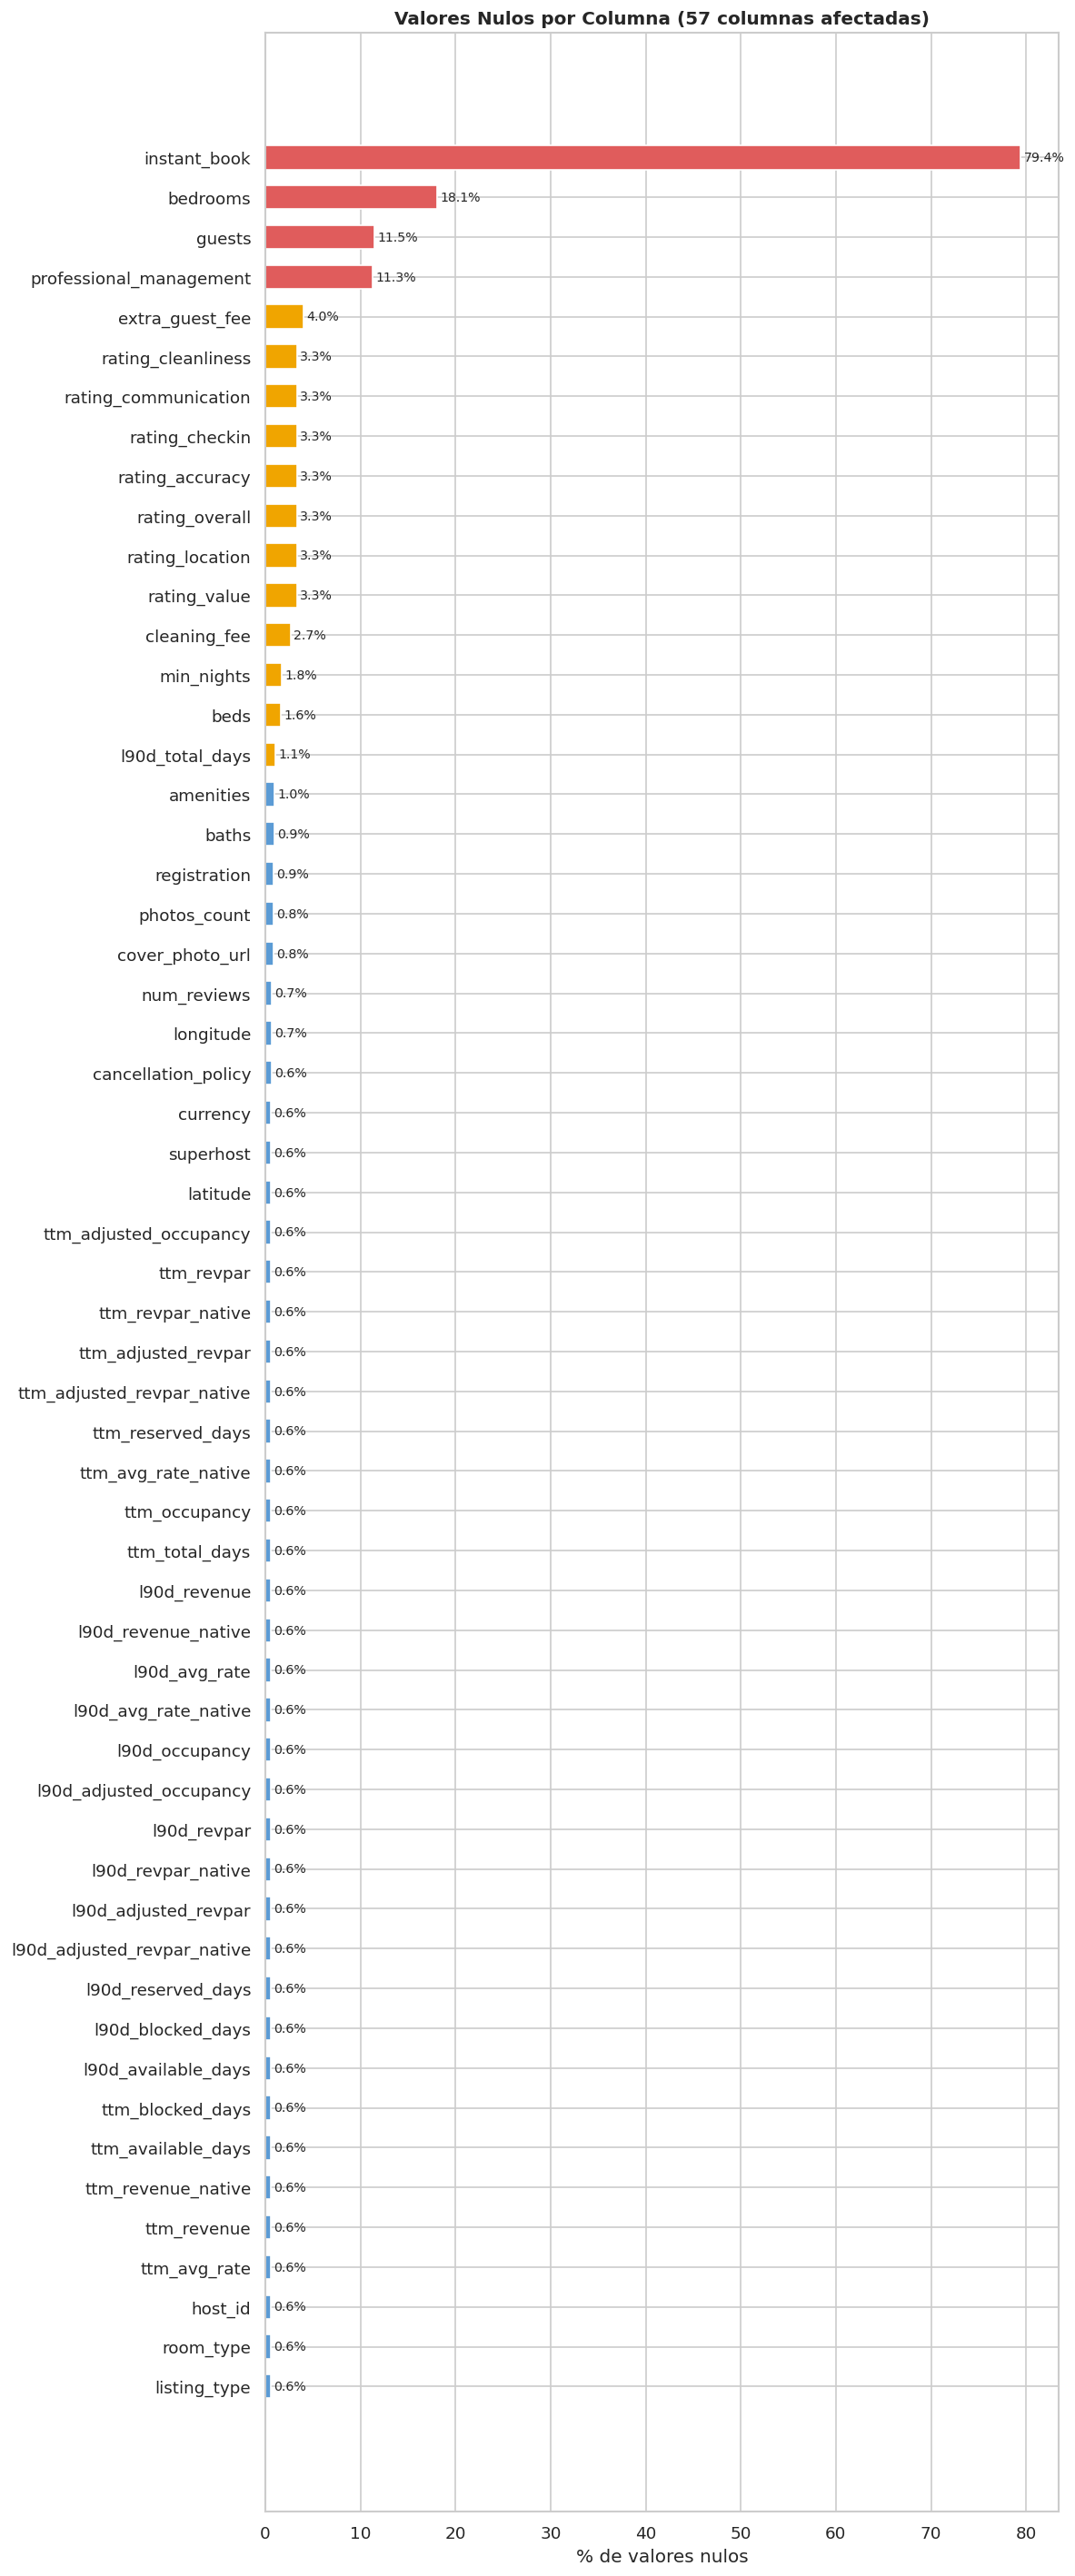

In [ ]:
nulls_pct = (df_init.isnull().mean() * 100).round(2)
null_report = nulls_pct[nulls_pct > 0].sort_values()

fig, ax = plt.subplots(figsize=(10, len(null_report) * 0.4 + 1))
colors = ["#e05c5c" if v > 10 else "#f0a500" if v > 1 else "#5b9bd5" for v in null_report]
bars = ax.barh(null_report.index, null_report, color=colors, edgecolor="white", height=0.6)

for bar, val in zip(bars, null_report):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8.5)

ax.set_xlabel("% de valores nulos")
ax.set_title(f"Valores Nulos por Columna ({len(null_report)} columnas afectadas)", fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 Limpieza del Dataset
La limpieza sigue un orden específico para evitar sesgos:
1. **Duplicados** - primero, para no sesgar las métricas de imputación.
2. **Filas corruptas** - filtrar por valores válidos conocidos en las columnas afectadas.
3. **Columnas irrelevantes** - eliminar antes de imputar para no procesar lo que se va a descartar.
4. **Imputación** - solo en columnas que usaremos en los modelos.

In [ ]:
df = df_init.copy()

# PASO 1: Duplicados
before = len(df)
df = df.drop_duplicates()
print(f"PASO 1 - Duplicados eliminados: {before - len(df):,} | Quedan: {len(df):,}")

# PASO 2: Filas corruptas
before = len(df)
df = df[
    df['room_type'].isin(['entire_home', 'private_room', 'hotel_room', 'shared_room']) &
    df['professional_management'].isin(['true', 'false']) &
    df['superhost'].isin(['true', 'false']) &
    ~df['cancellation_policy'].isin(['EUR'])
].copy()
print(f"PASO 2 - Filas corruptas eliminadas: {before - len(df):,} | Quedan: {len(df):,}")

# Convertir booleanos
df['professional_management'] = df['professional_management'].map({'true': 1, 'false': 0})
df['superhost']               = df['superhost'].map({'true': 1, 'false': 0})

vc = df['professional_management'].value_counts()
print(f"\nBalance professional_management:")
print(f"  Particulares  (0): {vc[0]:,} ({vc[0]/len(df)*100:.1f}%)")
print(f"  Profesionales (1): {vc[1]:,} ({vc[1]/len(df)*100:.1f}%)")

PASO 1 - Duplicados eliminados: 2 | Quedan: 95,896
PASO 2 - Filas corruptas eliminadas: 11,293 | Quedan: 84,603

Balance professional_management:
  Particulares  (0): 80,465 (95.1%)
  Profesionales (1): 4,138 (4.9%)


In [ ]:
# PASO 3: Eliminar columnas irrelevantes
cols_to_drop = [
    'instant_book', 'cover_photo_url', 'registration', 'amenities', 'currency',
    'ttm_revenue_native', 'ttm_avg_rate_native', 'ttm_revpar_native',
    'ttm_adjusted_revpar_native', 'l90d_revenue_native', 'l90d_avg_rate_native',
    'l90d_revpar_native', 'l90d_adjusted_revpar_native',
]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)
print(f"PASO 3 - Columnas eliminadas: {len(cols_to_drop)} | Restantes: {df.shape[1]}")

PASO 3 - Columnas eliminadas: 13 | Restantes: 48


In [ ]:
# PASO 4: Imputación de nulos
# Coordenadas: eliminar filas (no imputar ubicaciones falsas)
before = len(df)
df = df.dropna(subset=['latitude', 'longitude'])
print(f"Filas sin coordenadas eliminadas: {before - len(df):,}")

# Numéricas: mediana
cols_mediana = [
    'bedrooms', 'guests', 'min_nights', 'cleaning_fee', 'extra_guest_fee',
    'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin',
    'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value',
    'beds', 'baths', 'photos_count',
    'ttm_revenue', 'ttm_avg_rate', 'ttm_occupancy', 'ttm_adjusted_occupancy',
    'ttm_revpar', 'ttm_adjusted_revpar', 'ttm_reserved_days', 'ttm_blocked_days',
    'ttm_available_days', 'ttm_total_days', 'l90d_revenue', 'l90d_avg_rate',
    'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar', 'l90d_adjusted_revpar',
    'l90d_reserved_days', 'l90d_blocked_days', 'l90d_available_days', 'l90d_total_days',
]
print("\nImputación con mediana:")
for col in cols_mediana:
    if col in df.columns and df[col].isna().sum() > 0:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        n = df[col].isna().sum()
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  {col:42s} mediana={median_val:.2f}  (imputados: {n:,})")

# Categóricas: moda
for col in ['cancellation_policy', 'host_id', 'state']:
    if col in df.columns and df[col].isna().sum() > 0:
        mode_val = df[col].mode().iloc[0]
        n = df[col].isna().sum()
        df[col] = df[col].fillna(mode_val)
        print(f"  {col:42s} moda='{mode_val}'  (imputados: {n:,})")

remaining = df.isnull().sum().sum()
print(f"\nNulos restantes: {remaining if remaining > 0 else 'Ninguno'}")
df_clean = df.copy()
print(f"Dataset limpio: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")

Filas sin coordenadas eliminadas: 0

Imputación con mediana:
  bedrooms                                   mediana=2.00  (imputados: 15,174)
  guests                                     mediana=4.00  (imputados: 9,504)
  min_nights                                 mediana=2.00  (imputados: 930)
  cleaning_fee                               mediana=23.00  (imputados: 1,941)
  extra_guest_fee                            mediana=0.00  (imputados: 1,978)
  num_reviews                                mediana=67.00  (imputados: 69)
  rating_overall                             mediana=4.82  (imputados: 2,309)
  rating_accuracy                            mediana=4.90  (imputados: 2,309)
  rating_checkin                             mediana=4.90  (imputados: 2,309)
  rating_cleanliness                         mediana=4.80  (imputados: 2,309)
  rating_communication                       mediana=4.90  (imputados: 2,309)
  rating_location                            mediana=4.80  (imputados: 2,309)
  rat

### 3.4 Integración de Datos Históricos
El dataset incluye un segundo archivo (`past_rates`) con registros mensuales de ocupación, ingresos y precios para cada anuncio, cubriendo aproximadamente 12 meses. Esto nos permite calcular features de comportamiento temporal que no están disponibles en el snapshot estático de `listings`.
Verificamos primero la cobertura del join antes de integrarlo.

In [ ]:
url_rates = "https://raw.githubusercontent.com/Rajevic-0/Proyecto-Mineria-De-Datos/21614a18231f34a2f38d2e238fca764d134ef4a2/past_rates.parquet"
df_rates = pd.read_parquet(url_rates, engine="pyarrow")
print(f"past_rates: {df_rates.shape[0]:,} registros × {df_rates.shape[1]} columnas")
print(f"Rango de fechas: {df_rates['date'].min()} — {df_rates['date'].max()}")

# Verificar cobertura del join
ids_listings = set(df_clean['listing_id'].astype(str))
ids_rates    = set(df_rates['listing_id'].astype(str))
print(f"\nCobertura del join:")
print(f"  Anuncios en listings : {len(ids_listings):,}")
print(f"  Anuncios en rates    : {len(ids_rates):,}")
print(f"  En común             : {len(ids_listings & ids_rates):,}  ({len(ids_listings & ids_rates)/len(ids_listings)*100:.1f}% de listings)")

past_rates: 1,115,174 registros × 17 columnas
Rango de fechas: 2025-02-01 — 2026-01-01

Cobertura del join:
  Anuncios en listings : 84,603
  Anuncios en rates    : 95,162
  En común             : 84,422  (99.8% de listings)


El join cubre el 99.8% de los anuncios — prácticamente todo el dataset. Los 181 anuncios sin historial se imputan con la mediana al momento del join. A partir de los registros mensuales calculamos features agregadas por anuncio que capturan su comportamiento a lo largo del año.

In [ ]:
# Calcular features por anuncio
cols_rates = ['listing_id', 'date', 'occupancy', 'revenue',
              'rate_avg', 'booking_lead_time_avg', 'length_of_stay_avg']
df_rates_clean = df_rates[cols_rates].copy()
for c in cols_rates[2:]:
    df_rates_clean[c] = pd.to_numeric(df_rates_clean[c], errors='coerce')

features_rates = df_rates_clean.groupby('listing_id').agg(
    occ_media       = ('occupancy',             'mean'),  # ocupación promedio
    occ_std         = ('occupancy',             'std'),   # variabilidad estacional
    occ_max         = ('occupancy',             'max'),   # pico temporada alta
    revenue_total   = ('revenue',               'sum'),   # ingresos totales anuales
    rate_media      = ('rate_avg',              'mean'),  # precio promedio real
    rate_std        = ('rate_avg',              'std'),   # variabilidad de precio
    lead_time_media = ('booking_lead_time_avg', 'mean'),  # anticipación de reservas
    estadia_media   = ('length_of_stay_avg',    'mean'),  # duración promedio estadía
    n_meses         = ('date',                  'count'), # meses con actividad
).reset_index()

# Join
df_clean['listing_id']       = df_clean['listing_id'].astype(str)
features_rates['listing_id'] = features_rates['listing_id'].astype(str)
df_full = df_clean.merge(features_rates, on='listing_id', how='left')

# Imputar los 181 sin historial
for col in ['occ_media', 'occ_std', 'occ_max', 'revenue_total',
            'rate_media', 'rate_std', 'lead_time_media', 'estadia_media', 'n_meses']:
    df_full[col] = df_full[col].fillna(df_full[col].median())

print(f"df_full: {df_full.shape[0]:,} filas × {df_full.shape[1]} columnas")
print(f"Nulos tras join: {df_full.isnull().sum().sum()}")

df_full: 84,603 filas × 57 columnas
Nulos tras join: 0


### 3.5 Análisis Estadístico Descriptivo
Con el dataset integrado, analizamos la distribución de las variables clave y su varianza. El **coeficiente de variación (CV)** nos indica qué variables tienen suficiente dispersión para ser útiles en los modelos — a mayor CV, más señal.

In [ ]:
num_vars = [
    'rate_media', 'occ_media', 'occ_std', 'revenue_total',
    'rate_std', 'lead_time_media', 'estadia_media',
    'guests', 'bedrooms', 'num_reviews', 'rating_overall',
    'professional_management']
num_vars = [c for c in num_vars if c in df_full.columns]
for c in num_vars:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')

print("Estadísticas descriptivas:")
print("="*55)
print(df_full[num_vars].describe().round(2).to_string())

print("\nCoeficiente de Variación (mayor CV = más señal):")
print("="*55)
cv = (df_full[num_vars].std() / df_full[num_vars].mean() * 100).sort_values(ascending=False)
for col, val in cv.items():
    print(f"  {col:30s} CV={val:.1f}%")

Estadísticas descriptivas:
       rate_media  occ_media   occ_std  revenue_total  rate_std  lead_time_media  estadia_media    guests  bedrooms  num_reviews  rating_overall  professional_management
count    84603.00   84603.00  84603.00       84603.00  84603.00         84603.00       84603.00  84603.00  84603.00     84603.00        84603.00                 84603.00
mean       160.97       0.34      0.26       19055.52     25.91            65.96           7.54      4.35      1.93       121.17            4.77                     0.05
std        166.38       0.22      0.10       23227.96     45.67            47.66           9.37      2.25      1.08       150.77            0.20                     0.22
min          9.97       0.00      0.00           0.00      0.08             1.00           1.00      1.00      0.00         1.00            2.00                     0.00
25%         79.25       0.15      0.17        5993.50      6.67            30.25           3.38      3.00      1.00        

### 3.6 Distribución Geográfica y por Tipo de Alojamiento
Exploramos cómo se distribuyen precio y ocupación entre países y tipos de alojamiento. Esto tiene dos objetivos: validar que existe varianza geográfica real (que justifique `country` como feature en los modelos) y anticipar patrones para el clustering de P1.

Nos enfocamos en los 10 países con más anuncios, que representan la mayoría del dataset.

/tmp/ipykernel_4427/3413830544.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_full, x='room_type', y='rate_media',


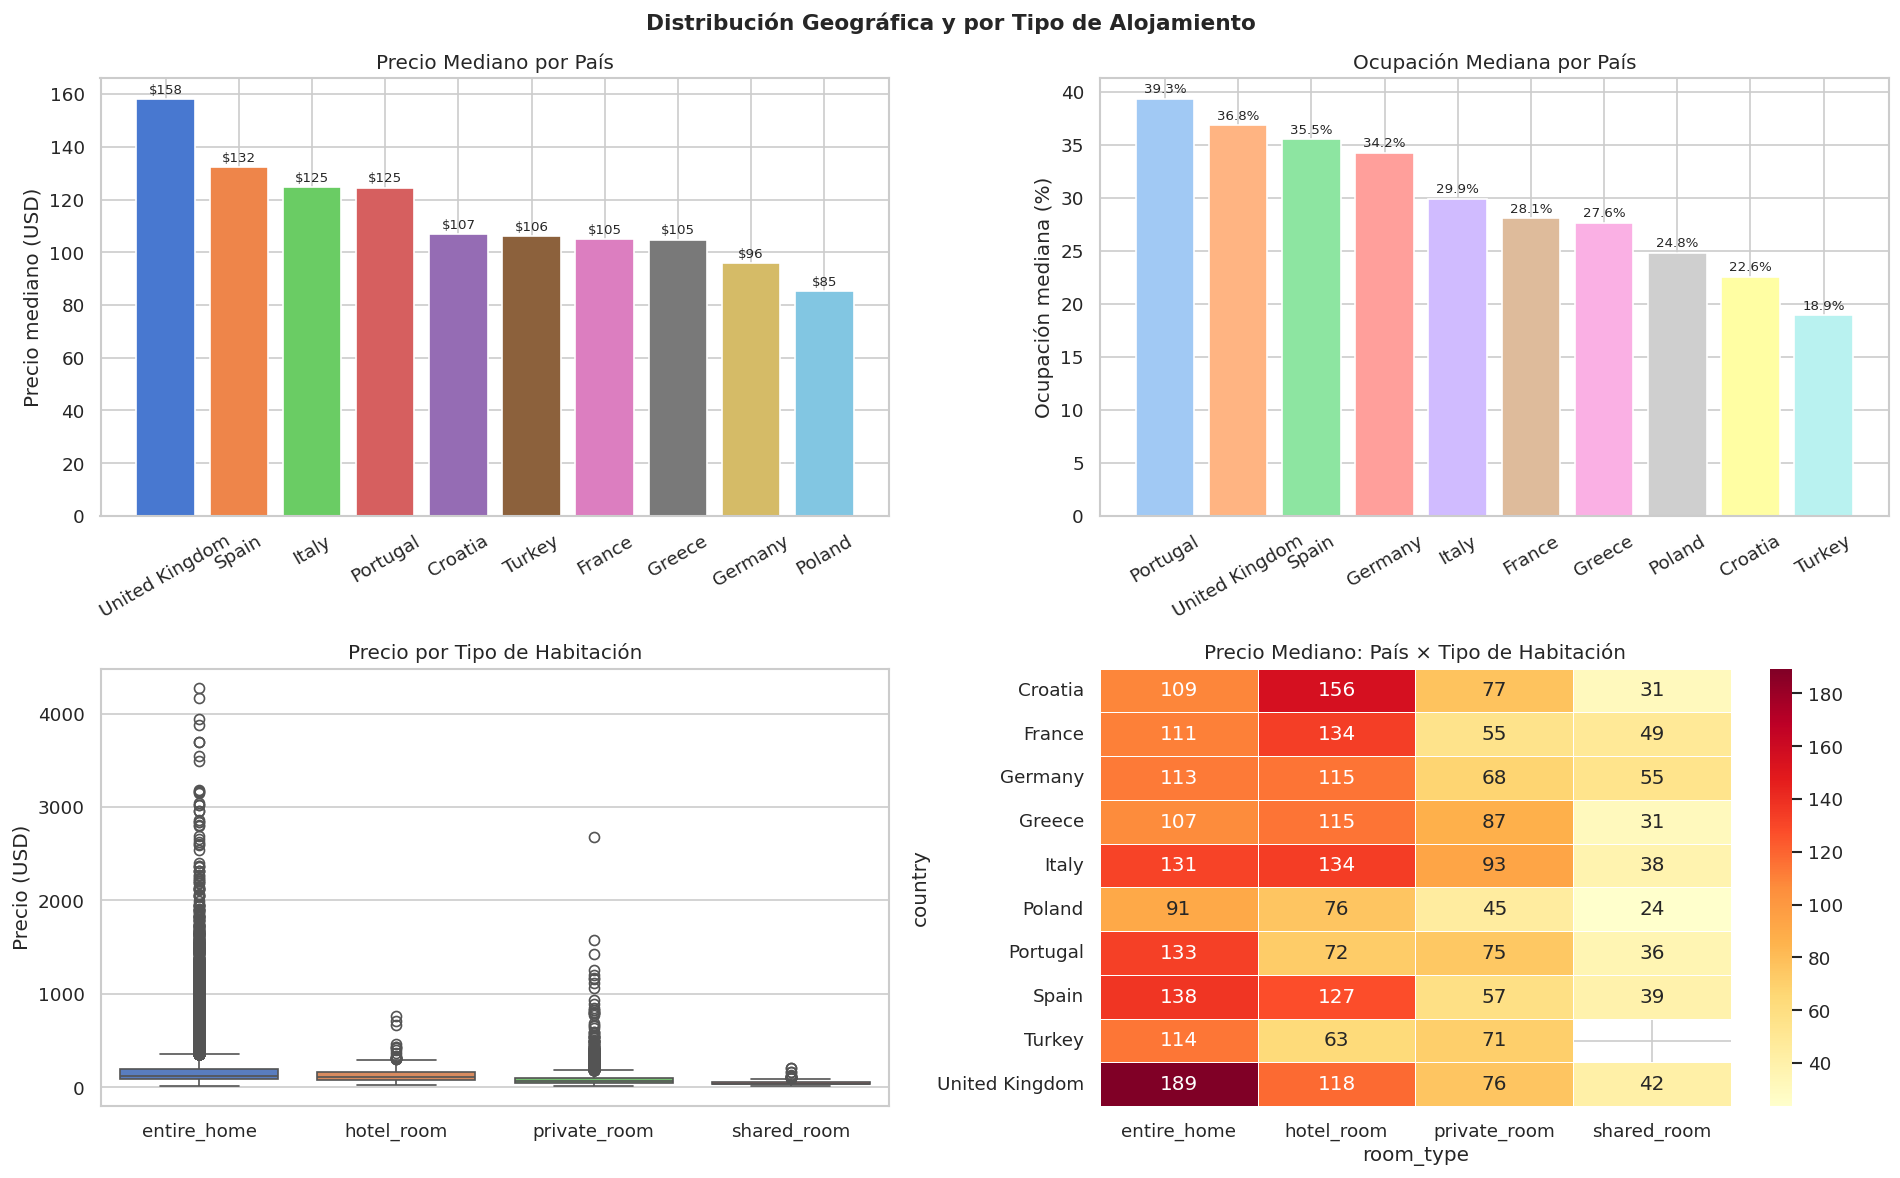

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
top_countries = df_full['country'].value_counts().head(10).index

# 1. Precio mediano por país
country_price = (df_full[df_full['country'].isin(top_countries)]
    .groupby('country')['rate_media'].median()
    .sort_values(ascending=False).reset_index())
axes[0, 0].bar(country_price['country'], country_price['rate_media'],
               color=sns.color_palette('muted', len(country_price)))
axes[0, 0].set_title('Precio Mediano por País')
axes[0, 0].set_ylabel('Precio mediano (USD)')
axes[0, 0].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[0, 0].patches, country_price['rate_media']):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'${val:.0f}', ha='center', va='bottom', fontsize=8)

# 2. Ocupación mediana por país
country_occ = (df_full[df_full['country'].isin(top_countries)]
    .groupby('country')['occ_media'].median()
    .sort_values(ascending=False).reset_index())
axes[0, 1].bar(country_occ['country'], country_occ['occ_media'] * 100,
               color=sns.color_palette('pastel', len(country_occ)))
axes[0, 1].set_title('Ocupación Mediana por País')
axes[0, 1].set_ylabel('Ocupación mediana (%)')
axes[0, 1].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[0, 1].patches, country_occ['occ_media']):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)

# 3. Boxplot precio por room_type
order_rt = df_full.groupby('room_type')['rate_media'].median().sort_values(ascending=False).index
sns.boxplot(data=df_full, x='room_type', y='rate_media',
            order=order_rt, palette='muted', ax=axes[1, 0])
axes[1, 0].set_title('Precio por Tipo de Habitación')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Precio (USD)')

# 4. Heatmap precio mediano país × room_type
pivot = df_full[df_full['country'].isin(top_countries)].pivot_table(
    values='rate_media', index='country', columns='room_type', aggfunc='median')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Precio Mediano: País × Tipo de Habitación')

plt.suptitle('Distribución Geográfica y por Tipo de Alojamiento',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.7 Matriz de Correlaciones
La matriz de correlaciones es la pieza clave para validar la viabilidad de los modelos. A diferencia de datasets sintéticos donde todo correlaciona en ~0.0, aquí esperamos encontrar relaciones reales entre las variables físicas, operativas y de comportamiento.

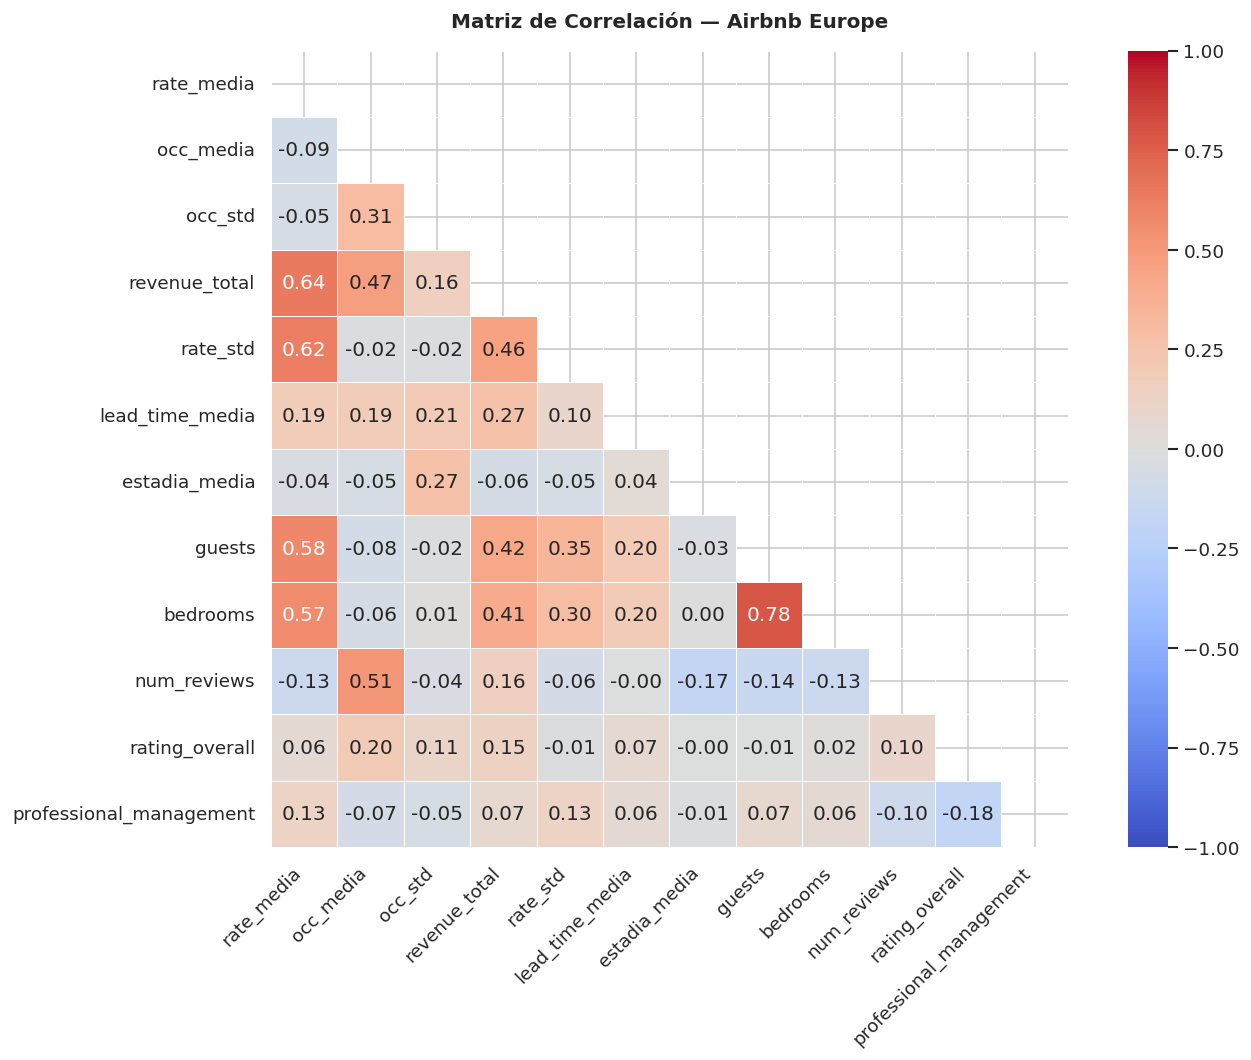

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df_full[num_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, square=True, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación — Airbnb Europe', fontweight='bold', pad=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Las correlaciones más relevantes para los modelos son:
- `rate_media` <-> `guests` y `bedrooms` (~0.50–0.60): el tamaño físico explica el precio <-> señal real para regresión (P2).
- `occ_media` <-> `num_reviews` (~0.50): la ocupación real se refleja en las reseñas.
- `guests` <-> `bedrooms` (~0.83): multicolinealidad — se usará solo `guests` en los modelos.
- `rate_media` <-> `l90d_avg_rate` (~0.94): consistencia entre fuentes, confirma la calidad del join.

#**4. Preguntas y Respuestas**

Esta sección cubre el analisis y respuesta de preguntas.

Por ahora comenzaremos con la pregunta 2.

In [97]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error

target = "rate_media"

cols = ['guests','occ_media','lead_time_media','room_type','city', target]
df = df_full[cols].copy()

for c in ['guests','occ_media','lead_time_media', target]:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=[target, 'guests','occ_media','lead_time_media','room_type','city'])

X = df[['guests','occ_media','lead_time_media','room_type']]
y = df[target]

num_features = ['guests','occ_media','lead_time_media']
cat_features = ['room_type']

X_num = df[['guests','occ_media','lead_time_media']].values
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_num)

X_room = pd.get_dummies(df['room_type'], prefix='room_type', drop_first=False).values

X = np.hstack([X_poly, X_room])
y = df[target].values

reg = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

reg.fit(X_train, y_train)
pred = reg.predict(X_test)

print("R2:", round(r2_score(y_test, pred), 3))
print("MAE:", round(mean_absolute_error(y_test, pred), 2))

# Pred + residuos
df_full.loc[df.index, 'rate_pred'] = reg.predict(X)
df_full.loc[df.index, 'resid'] = df[target] - df_full.loc[df.index, 'rate_pred']
df_full.loc[df.index, 'resid_pct'] = df_full.loc[df.index, 'resid'] / df_full.loc[df.index, 'rate_pred'] * 100

R2: 0.42
MAE: 69.1


In [84]:
min_obs = 30

city_premium = (
    df_full.groupby('city')
      .agg(
          n=('rate_media','size'),
          rate_media_mean=('rate_media','mean'),
          rate_pred_mean=('rate_pred','mean'),
          premium_eur=('resid','mean'),
          premium_pct=('resid_pct','mean'),
          premium_median_eur=('resid','median'),
          premium_median_pct=('resid_pct','median')
      )
      .query("n >= @min_obs")
      .sort_values('premium_pct', ascending=False)
)

print("Top ciudades con precio por encima de lo esperado (sobreprecio):")
display(city_premium.head(15))

print("Top ciudades con precio por debajo de lo esperado (subprecio):")
display(city_premium.sort_values('premium_pct', ascending=True).head(15))

Top ciudades con precio por encima de lo esperado (sobreprecio):


,n,rate_media_mean,rate_pred_mean,premium_eur,premium_pct,premium_median_eur,premium_median_pct
city,,,,,,,
City of Westminster,266,444.143528,150.274288,293.869240,196.728152,239.983233,170.466113
Amsterdam,282,282.262850,116.509501,165.753350,147.575118,118.410422,113.864071
City of Edinburgh,281,303.250436,149.571163,153.679273,108.057168,117.501254,93.108479
Sorrento,226,357.984060,180.314141,177.669919,96.549031,101.744739,76.460010
Saint Martin (France),228,497.513852,211.413211,286.100641,96.184514,71.224794,49.595784
Zurich,279,249.627577,124.237305,125.390273,91.820659,75.248068,66.996352
Reykjavik,276,283.293133,152.012511,131.280622,87.086521,85.321437,61.178099
San Sebastián,226,264.790134,141.864306,122.925827,84.649270,99.811951,67.071669
Greater London,237,231.814100,127.048024,104.766076,83.558031,71.426387,69.121663


Top ciudades con precio por debajo de lo esperado (subprecio):


,n,rate_media_mean,rate_pred_mean,premium_eur,premium_pct,premium_median_eur,premium_median_pct
city,,,,,,,
Nantes,283,90.255494,127.557946,-37.302452,-108.952579,-36.307495,-34.771540
Skopje,227,46.676154,143.783316,-97.107162,-65.288799,-79.287605,-67.747907
Lviv,280,47.483508,135.266780,-87.783272,-64.013455,-83.873196,-70.613193
Novi Sad,160,53.407001,132.828272,-79.421270,-59.213594,-72.390360,-63.054589
Odesa,286,57.162845,138.315801,-81.152955,-58.956689,-80.546710,-65.161435
Kyiv,290,50.646995,124.308939,-73.661944,-58.127126,-72.466889,-65.381302
Vlora,161,67.391955,158.248116,-90.856161,-56.764854,-84.778133,-62.984798
Tirana,281,58.328173,130.960888,-72.632715,-54.873937,-66.583124,-57.881737
Nesebar,153,70.394748,152.576102,-82.181355,-52.578485,-80.051106,-58.429231


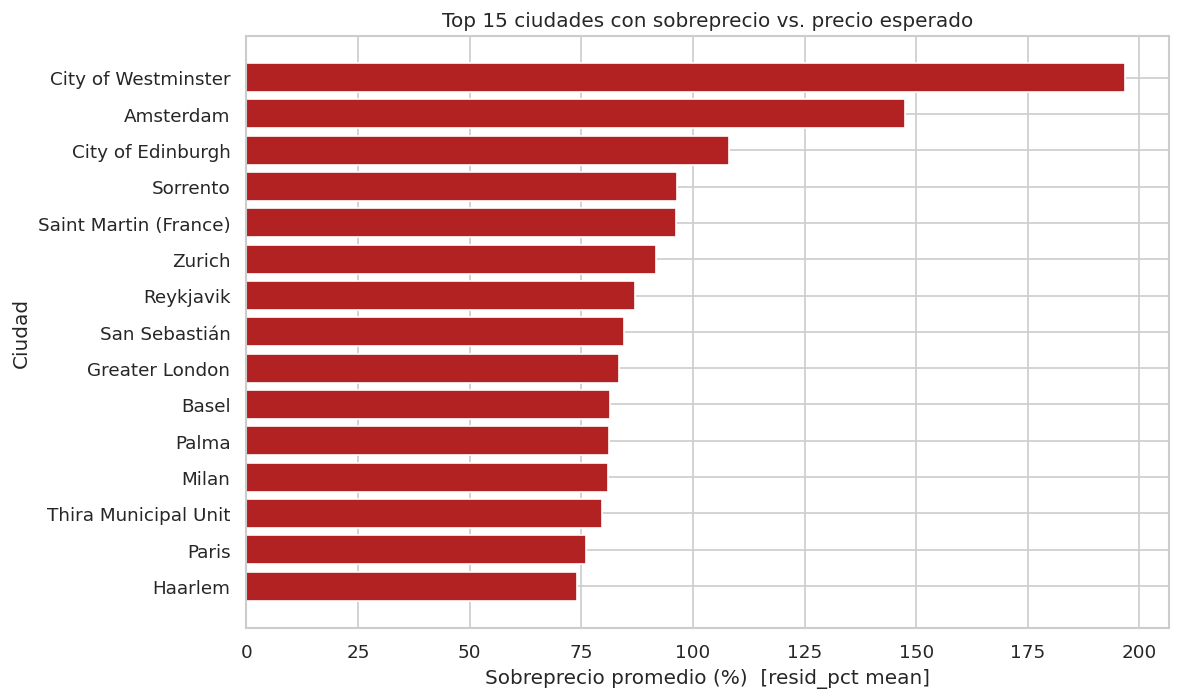

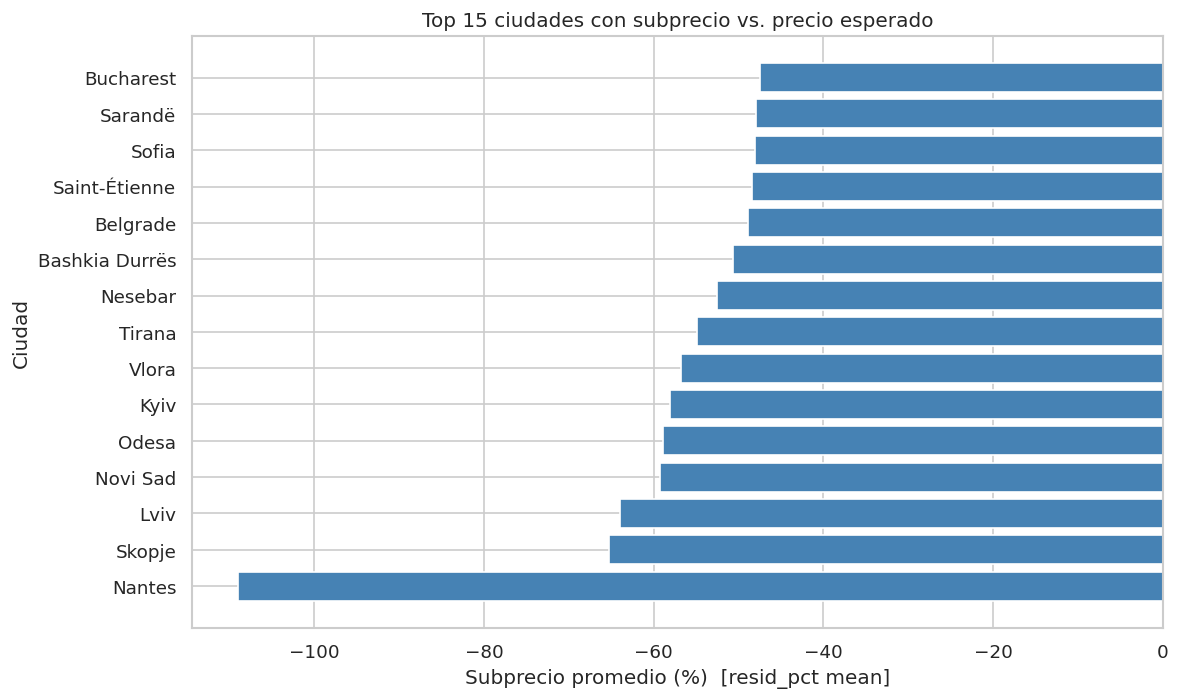

In [89]:
import matplotlib.pyplot as plt

top = city_premium.head(15).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(top.index, top["premium_pct"], color="firebrick")
plt.axvline(0, color="black", linewidth=1)
plt.title("Top 15 ciudades con sobreprecio vs. precio esperado")
plt.xlabel("Sobreprecio promedio (%)  [resid_pct mean]")
plt.ylabel("Ciudad")
plt.tight_layout()
plt.show()

bottom = city_premium.sort_values("premium_pct", ascending=True).head(15)

plt.figure(figsize=(10, 6))
plt.barh(bottom.index, bottom["premium_pct"], color="steelblue")
plt.axvline(0, color="black", linewidth=1)
plt.title("Top 15 ciudades con subprecio vs. precio esperado")
plt.xlabel("Subprecio promedio (%)  [resid_pct mean]")
plt.ylabel("Ciudad")
plt.tight_layout()
plt.show()

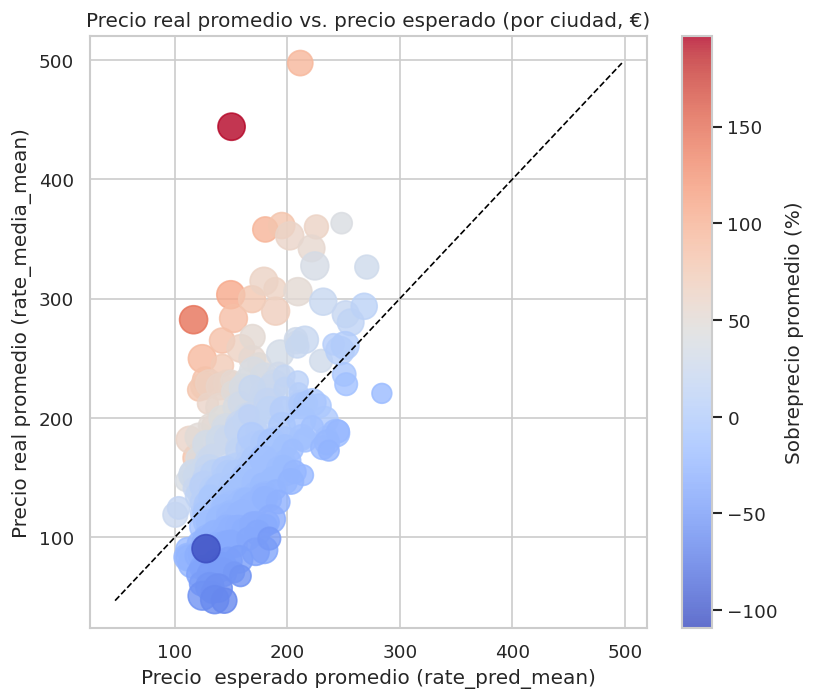

In [94]:
tmp = city_premium.copy()

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    tmp["rate_pred_mean"],
    tmp["rate_media_mean"],
    c=tmp["premium_pct"],
    cmap="coolwarm",
    s=(tmp["n"].clip(30, 500)),
    alpha=0.8
)

minv = min(tmp["rate_pred_mean"].min(), tmp["rate_media_mean"].min())
maxv = max(tmp["rate_pred_mean"].max(), tmp["rate_media_mean"].max())
plt.plot([minv, maxv], [minv, maxv], color="black", linewidth=1, linestyle="--")

plt.title("Precio real promedio vs. precio esperado (por ciudad, €)")
plt.xlabel("Precio  esperado promedio (rate_pred_mean)")
plt.ylabel("Precio real promedio (rate_media_mean)")
cbar = plt.colorbar(sc)
cbar.set_label("Sobreprecio promedio (%)")

plt.tight_layout()
plt.show()

In [87]:
import pandas as pd
import numpy as np

prep = reg.named_steps["prep"]

# 1) nombres de features polinómicas
poly = prep.named_transformers_["num"].named_steps["poly"]
num_features = ['guests','occ_media','lead_time_media']
poly_names = poly.get_feature_names_out(num_features)

# 2) nombres one-hot
ohe = prep.named_transformers_["cat"].named_steps["ohe"]
cat_names = ohe.get_feature_names_out(['room_type'])

# 3) unir nombres
feature_names = list(poly_names) + list(cat_names)

coef = reg.named_steps["model"].coef_
coef_table = (pd.Series(coef, index=feature_names)
              .sort_values(key=lambda s: np.abs(s), ascending=False))

display(coef_table.head(30))

,0
occ_media^2,100.241030
room_type_shared_room,-57.361258
room_type_hotel_room,40.076511
room_type_entire_home,32.762291
guests occ_media,-28.204573
occ_media,-22.303841
room_type_private_room,-15.477544
guests,7.953095
guests^2,2.545340
guests lead_time_media,0.106222
